In [1]:
import numpy as np
from sklearn.model_selection import KFold, cross_val_score, cross_validate, GroupKFold, LeaveOneGroupOut, learning_curve
from sklearn.ensemble import HistGradientBoostingRegressor
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
# this dataset is a composition feature matrix for B-site alloy halide perovskites which I generated using matminer and my PhD research.
# this dataset does not contain any dos-related features
# there are multiple possible targets to predict, Eg, dHf, and dHd. For this notebook, we will focus on predicting Eg.
my_df = pd.read_parquet('parquet/composition_feature_matrix.parquet')

# these are the non-feature columns in the dataframe, which we will drop before training the model
non_feature_cols = ['formula', 'alloy_id', 'A1', 'A2', 'B1', 'B2', 'X', 'is_alloy', 'x_frac', 'Eg', 'dHf', 'dHd']

In [3]:
# There are multiple ways my dataset can be grouped. Alloy ID is a unique identifier for each alloy indicated by their x=0.5 composition.
# Currently, alloy_id is a string, but we can convert it to a categorical integer for use in cross-validation.
# non-alloys have the label 'None' and should be assigned a unique integer as well. We will use the pandas factorize function to do this.

my_df['alloy_id_factorized'] = pd.factorize(my_df['alloy_id'])[0]

#create a dictionary to map the factorized integers back to the original alloy_id strings
alloy_id_mapping = dict(zip(my_df['alloy_id_factorized'], my_df['alloy_id']))
alloy_id_mapping[-1] = 'non-alloy' # assign the label 'non-alloy' to the -1 integer

# sklearn can parse group labels as either strings or integers, 
# but this is good practice in converting string labels to integers even though it is not necessary in this case.
# it is safer to use the factorized column as some algorithms ignore 'None', 
# which would be bad in my case here as they indicate non-alloy compositions

In [50]:
# another way to group the dataset is by their B1 and B2 site.
# we want to make sure that (B1, B2) of (Ni, Co) is the same as (Co, Ni), so we should sort the pair

my_df['B_pair'] = my_df[['B1','B2']].apply(
    lambda r: '-'.join(sorted([str(r['B1']), str(r['B2'])])), axis=1) # this is a lambda function that applies the sorted labeling

In [53]:
print(my_df['B_pair'].nunique())
print(my_df.groupby('B_pair').size().describe())

135
count    135.000000
mean      48.288889
std       24.653075
min        3.000000
25%       29.000000
50%       48.000000
75%       64.500000
max      134.000000
dtype: float64


In [4]:
# check the distribution of the number of samples per alloy_id. It should average at about 3 (x = 0.25, 0.5, 0.75)
# but there are some alloys with only 1 or 2 samples due to convergence issues in the DFT calculations.
print(my_df.groupby('alloy_id').size().describe())

count    2037.000000
mean        2.941581
std         0.273276
min         1.000000
25%         3.000000
50%         3.000000
75%         3.000000
max         3.000000
dtype: float64


In [5]:
# Check which alloy_id has less than 3 members
sizes = my_df.groupby('alloy_id').size()
print(sizes[sizes < 3])

# only 99 out of 2037 groups. acceptable. We could choose to exclude these groups, but I will include them in this notebook
# because their non-alloy endpoints are present in the dataset

alloy_id
Cs2CaNiI6      2
Cs2CoPtCl6     2
Cs2MgCoI6      2
Cs2MnCoF6      2
Cs2MnNiI6      2
              ..
RbCsNiPbI6     1
RbCsNiSnI6     2
RbCsNiSrI6     2
RbCsPdPtCl6    1
RbCsTiBaF6     2
Length: 99, dtype: int64


In [6]:
# Check that only non-alloys (None) has more than 3 members
# 'None' is not recognized by pandas, so we check with alloy_id_factorized (only group -1 should appear)
sizes = my_df.groupby('alloy_id_factorized').size()
print(sizes[sizes > 3])

# only -1 or non-alloys. good

alloy_id_factorized
-1    527
dtype: int64


In [7]:
# Potentially interesting observation:
# Check which element is most prevelant for size < 3 groups. Could be indicative of the chemistry of elements.
# uncomment code below to check, but the observation in this cell is not important in this notebook as it will involve more advanced
# investigations.

# sizes = my_df.groupby('alloy_id').size()
# short = sizes[sizes < 3].index
# print(my_df[my_df['alloy_id'].isin(short)]['B1'].value_counts())
# print(my_df[my_df['alloy_id'].isin(short)]['B2'].value_counts())

In [42]:
# the non-feature columns in the dataframe should now include the factorized alloy_id column
non_feature_cols = ['formula', 'alloy_id', 'alloy_id_factorized', 'A1', 'A2', 'B1', 'B2', 'X', 'is_alloy', 'B_pair' 'x_frac', 'Eg', 'dHf', 'dHd']

In [9]:
# convert the dataframe to a numpy array for use with sklearn
X = my_df.drop(columns=non_feature_cols).values

# grab the target column, Eg, and convert it to a numpy array
y = my_df['Eg'].values

In [14]:
# CVs and model setup. Informed by D1's tests

cv1 = KFold(n_splits=5, shuffle=True, random_state=0) # Ungrouped 5-fold cross validation, with shuffling
cv2 = GroupKFold(n_splits=5) # Grouped 5-fold cross validation, with shuffling
cv3 = LeaveOneGroupOut()
model = HistGradientBoostingRegressor(random_state=0)

In [27]:
g

array([ 0,  0,  0, ..., -1, -1, -1], dtype=int64)

In [16]:
# CV

# Ungrouped 5-fold CV, shuffled
res = cross_validate(model, X, y, cv = cv1, groups = my_df['alloy_id_factorized'], scoring = 'neg_mean_absolute_error',
                     return_train_score = True)
print(f"Ungrouped 5-fold CV, shuffled scores:")
print(f"    MAE: {res['test_score'].mean():.3f} +/- {res['test_score'].std():.3f}")
print(f"    per-fold: {np.round(res['test_score'], 3)}")
print(f"    runtime: {res['fit_time'].sum() + res['score_time'].sum():.2f} s total")
print('----------------------------------------------')

# Grouped 5-fold CV
res_grouped = cross_validate(model, X, y, cv = cv2, groups = my_df['alloy_id_factorized'], scoring = 'neg_mean_absolute_error',
                              return_train_score = True)
print(f"Grouped 5-fold CV scores:")
print(f"    MAE: {res_grouped['test_score'].mean():.3f} +/- {res_grouped['test_score'].std():.3f}")
print(f"    per-fold: {np.round(res_grouped['test_score'], 3)}")
print(f"    runtime: {res_grouped['fit_time'].sum() + res_grouped['score_time'].sum():.2f} s total")
print('----------------------------------------------')


Ungrouped 5-fold CV, shuffled scores:
    MAE: -0.074 +/- 0.002
    per-fold: [-0.072 -0.079 -0.074 -0.074 -0.072]
    runtime: 28.66 s total
----------------------------------------------
Grouped 5-fold CV scores:
    MAE: -0.082 +/- 0.015
    per-fold: [-0.111 -0.076 -0.071 -0.079 -0.073]
    runtime: 28.02 s total
----------------------------------------------


In [39]:
g = my_df['alloy_id_factorized'].values
for i, (tr, te) in enumerate(cv2.split(X, y, groups=g), 1):
    # tr and te are outputs of indices mapped to g.
    print(f"fold {i}: non-alloys in test = {(-1 in g[te])}, n_train = {len(tr)}, n_test = {len(te)}")

    
    # print(len(set(g[tr]) & set(g[te])))   # must all be 0

fold 1: non-alloys in test = True, n_train = 5215, n_test = 1304
fold 2: non-alloys in test = False, n_train = 5215, n_test = 1304
fold 3: non-alloys in test = False, n_train = 5215, n_test = 1304
fold 4: non-alloys in test = False, n_train = 5215, n_test = 1304
fold 5: non-alloys in test = False, n_train = 5216, n_test = 1303


In [54]:
# CV

# Ungrouped 5-fold CV, shuffled
res = cross_validate(model, X, y, cv = cv1, groups = my_df['B_pair'], scoring = 'neg_mean_absolute_error',
                     return_train_score = True)
print(f"Ungrouped 5-fold CV, shuffled scores:")
print(f"    MAE: {res['test_score'].mean():.3f} +/- {res['test_score'].std():.3f}")
print(f"    per-fold: {np.round(res['test_score'], 3)}")
print(f"    runtime: {res['fit_time'].sum() + res['score_time'].sum():.2f} s total")
print('----------------------------------------------')

# Grouped 5-fold CV
res_grouped = cross_validate(model, X, y, cv = cv2, groups = my_df['B_pair'], scoring = 'neg_mean_absolute_error',
                              return_train_score = True)
print(f"Grouped 5-fold CV scores:")
print(f"    MAE: {res_grouped['test_score'].mean():.3f} +/- {res_grouped['test_score'].std():.3f}")
print(f"    per-fold: {np.round(res_grouped['test_score'], 3)}")
print(f"    runtime: {res_grouped['fit_time'].sum() + res_grouped['score_time'].sum():.2f} s total")
print('----------------------------------------------')

Ungrouped 5-fold CV, shuffled scores:
    MAE: -0.074 +/- 0.002
    per-fold: [-0.072 -0.079 -0.074 -0.074 -0.072]
    runtime: 26.69 s total
----------------------------------------------
Grouped 5-fold CV scores:
    MAE: -0.144 +/- 0.023
    per-fold: [-0.118 -0.171 -0.165 -0.15  -0.117]
    runtime: 26.63 s total
----------------------------------------------


In [ ]:
# Leave One Group Out CV
# grouped by B1 B2 combination
res_LOGO = cross_validate(model, X, y, cv = cv3, groups = my_df['B_pair'], scoring = 'neg_mean_absolute_error',
                              return_train_score = True)
print(f"Leave One Group Out scores:")
print(f"    MAE: {res_LOGO['test_score'].mean():.3f} +/- {res_LOGO['test_score'].std():.3f}")
print(f"    per-fold: {np.round(res_LOGO['test_score'], 3)}")
print(f"    runtime: {res_LOGO['fit_time'].sum() + res_LOGO['score_time'].sum():.2f} s total")
print('----------------------------------------------')

Leave One Group Out scores:
    MAE: -0.136 +/- 0.117
    per-fold: [-0.119 -0.169 -0.069 -0.062 -0.017 -0.046 -0.18  -0.141 -0.127 -0.118
 -0.129 -0.176 -0.109 -0.033 -0.107 -0.121 -0.191 -0.081 -0.044 -0.018
 -0.059 -0.192 -0.077 -0.11  -0.169 -0.114 -0.047 -0.249 -0.108 -0.055
 -0.074 -0.231 -0.111 -0.052 -0.024 -0.088 -0.266 -0.637 -0.122 -0.357
 -0.184 -0.296 -0.365 -0.098 -0.035 -0.25  -0.171 -0.018 -0.049 -0.019
 -0.068 -0.051 -0.072 -0.056 -0.146 -0.025 -0.076 -0.056 -0.259 -0.102
 -0.011 -0.066 -0.084 -0.022 -0.042 -0.08  -0.051 -0.047 -0.218 -0.065
 -0.01  -0.037 -0.105 -0.056 -0.035 -0.027 -0.034 -0.01  -0.044 -0.069
 -0.125 -0.023 -0.025 -0.104 -0.088 -0.045 -0.112 -0.504 -0.185 -0.322
 -0.309 -0.26  -0.242 -0.142 -0.084 -0.216 -0.227 -0.086 -0.328 -0.392
 -0.487 -0.108 -0.035 -0.269 -0.561 -0.157 -0.187 -0.125 -0.091 -0.113
 -0.108 -0.075 -0.049 -0.256 -0.121 -0.036 -0.091 -0.362 -0.091 -0.202
 -0.117 -0.059 -0.12  -0.291 -0.038 -0.11  -0.36  -0.136 -0.027 -0.21
 -0.265 -0

In [64]:
g

array([ 0,  0,  0, ..., -1, -1, -1], dtype=int64)

In [66]:
g = my_df['B_pair'].values
for i, (tr, te) in enumerate(cv3.split(X, y, groups=g), 1):
    # tr and te are outputs of indices mapped to g.
    if -res_LOGO['test_score'][i-1] > 0.5:
        print(f"fold {i}: MAE = {res_LOGO['test_score'][i-1]:.3f}, test_group = {g[i-1]}")

fold 38: MAE = -0.637, test_group = Ca-Mn
fold 88: MAE = -0.504, test_group = Ca-Mg
fold 105: MAE = -0.561, test_group = Ca-Mn


In [57]:
# Learning curve with Grouped 5-fold CV

train_sizes = np.linspace(0.1, 1.0, 8)

# 5-fold cross validation, no shuffling
sizes, train_scores, val_scores, fit_times, score_times = learning_curve(
    model, X, y, cv = cv1,
    groups = my_df['alloy_id_factorized'],
    scoring = "neg_mean_absolute_error",
    train_sizes = train_sizes, return_times = True)

train_mae, val_mae = -train_scores, -val_scores

# 5-fold cross validation, shuffled
sizes_grouped, train_scores_grouped, val_scores_grouped, fit_times_grouped, score_times_grouped = learning_curve(
    model, X, y, cv = cv2,
    groups = my_df['alloy_id_factorized'],
    scoring = "neg_mean_absolute_error",
    train_sizes = train_sizes, return_times = True)

train_mae_grouped, val_mae_grouped = -train_scores_grouped, -val_scores_grouped

In [58]:
print(f"Ungrouped 5-fold CV, shuffled scores:")
total_runtime = 0
for train_size, train_fit_time, train_score_time in zip(sizes, fit_times, train_mae):
    runtime = train_fit_time.sum() + train_score_time.sum()
    print(f"Train size: {train_size}, Fit time: {runtime:.1f}s")
    total_runtime += runtime
print(f"Total runtime (no shuffling): {total_runtime:.1f}s")
print()

print(f"Grouped 5-fold CV scores:")
total_runtime = 0
for train_size, train_fit_time, train_score_time in zip(sizes_grouped, fit_times_grouped, train_mae_grouped):
    runtime = train_fit_time.sum() + train_score_time.sum()
    print(f"Train size: {train_size}, Fit time: {runtime:.1f}s")
    total_runtime += runtime
print(f"Total runtime (shuffled): {total_runtime:.1f}s")

Ungrouped 5-fold CV, shuffled scores:
Train size: 521, Fit time: 27.0s
Train size: 1192, Fit time: 39.4s
Train size: 1862, Fit time: 40.0s
Train size: 2533, Fit time: 48.5s
Train size: 3203, Fit time: 44.6s
Train size: 3874, Fit time: 43.0s
Train size: 4544, Fit time: 43.4s
Train size: 5215, Fit time: 48.3s
Total runtime (no shuffling): 334.2s

Grouped 5-fold CV scores:
Train size: 521, Fit time: 21.1s
Train size: 1192, Fit time: 36.7s
Train size: 1862, Fit time: 33.6s
Train size: 2533, Fit time: 22.1s
Train size: 3203, Fit time: 32.8s
Train size: 3874, Fit time: 34.5s
Train size: 4544, Fit time: 39.7s
Train size: 5215, Fit time: 34.3s
Total runtime (shuffled): 254.8s


In [59]:
def plot_learning_curve(sizes, train_mae, val_mae, title="Learning Curve", xlabel="Training Set Size", ylabel="MAE"):
    plt.figure(figsize=(8, 6))
    plt.errorbar(sizes, val_mae.mean(1), yerr = val_mae.std(1),
                 marker = "o", label = "validation")
    plt.errorbar(sizes, train_mae.mean(1), yerr = train_mae.std(1),
                 marker = "s", label = "train")
    plt.title(title); plt.xlabel(xlabel); plt.ylabel(ylabel); plt.legend()
    plt.show()

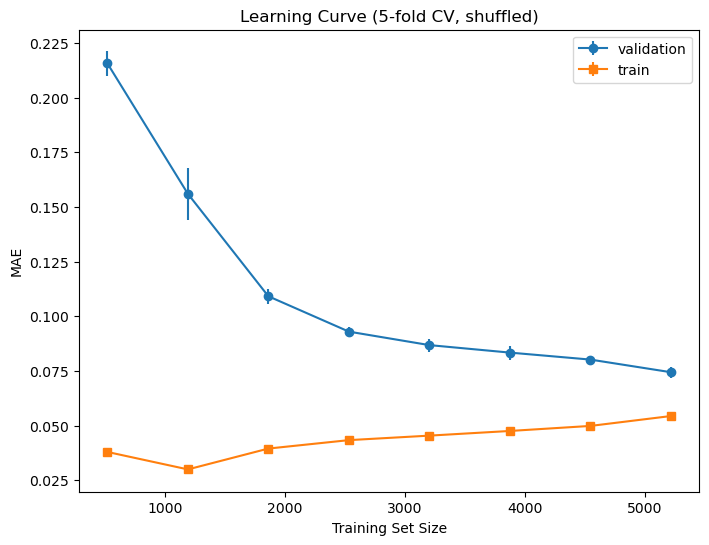

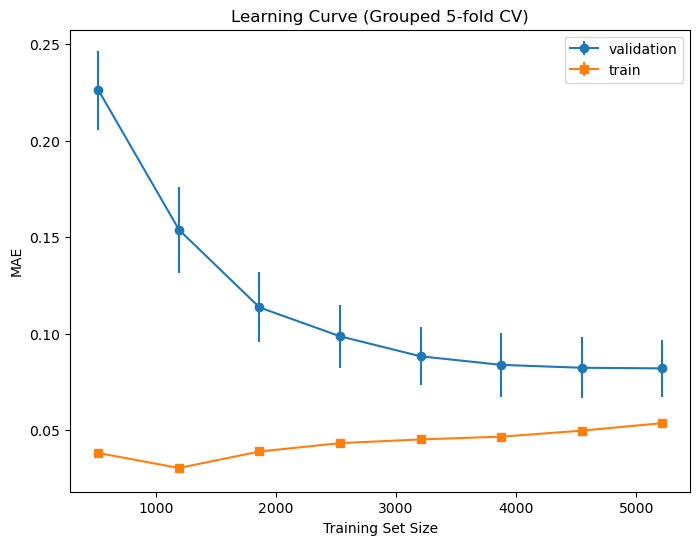

In [61]:
plot_learning_curve(sizes, train_mae, val_mae, title="Learning Curve (5-fold CV, shuffled)")
plot_learning_curve(sizes_grouped, train_mae_grouped, val_mae_grouped, title="Learning Curve (Grouped 5-fold CV)")

In [ ]:
# My learning curves show that validation MAE reduced with dataset size and the gradient decreased, 
# which suggests to me improvements to prediction at the amount of data I have will come more from improving my features 
# instead of running more calculations.

# One thing to note is that there is a difference in the validation and training MAE even at the largest training set size,
# i.e. the model is not converging. This could be because the Magpie features I use do not fully capture the physics of the problem.
# Structural and site ordering features may be the important missing piece for the training and validation MAE to converge.
# This difference is also not 'fixable' with more data, and is a motivation for models that are more structure-aware.